# Plot Protein LM Training Metrics

Read `training_metrics.jsonl` and optional `resume_training_metrics.jsonl` from the protein checkpoint directory, then plot train and validation loss against optimizer steps.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def find_repo_dir_for_import(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    repo_dir_env = os.environ.get("MDNAC_REPO_DIR")
    if repo_dir_env:
        candidates.append(Path(repo_dir_env).expanduser())
    candidates.extend([
        Path("/content/MDNAC"),
        Path("/content/drive/MyDrive/MDNAC"),
    ])
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if (resolved / "pyproject.toml").exists() and (resolved / "libs").is_dir():
            return resolved
    raise RuntimeError(
        "Could not locate repo. Run inside the repo, set MDNAC_REPO_DIR, "
        "or in Colab clone/mount the repo under /content or Google Drive."
    )


PROJECT_ROOT = find_repo_dir_for_import(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from libs.notebook_runtime import bootstrap_notebook
from libs.core.pretrain.training_config import load_protein_training_config

RUNTIME = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = Path(RUNTIME["repo_dir"])
CONFIG_PATH = Path(os.environ.get("MDNAC_TRAIN_CONFIG", PROJECT_ROOT / "config" / "train.16gb.yaml")).expanduser()
if not CONFIG_PATH.is_absolute():
    CONFIG_PATH = (PROJECT_ROOT / CONFIG_PATH).resolve()
TRAINING_CONFIG = load_protein_training_config(PROJECT_ROOT, config_path=CONFIG_PATH)
CHECKPOINT_DIR = TRAINING_CONFIG["paths"]["checkpoint_dir"]
METRIC_FILES = [
    CHECKPOINT_DIR / "metrics_history.jsonl",
    CHECKPOINT_DIR / "training_metrics.jsonl",
    CHECKPOINT_DIR / "resume_training_metrics.jsonl",
]
PLOT_PATH = CHECKPOINT_DIR / "loss_curve.png"

{"runtime": RUNTIME, "config_path": str(CONFIG_PATH), "checkpoint_dir": str(CHECKPOINT_DIR)}


{'runtime': {'repo_dir': 'C:\\Users\\Admin\\Desktop\\MDNAC',
  'platform': 'Windows',
  'platform_name': 'Windows',
  'is_colab': False,
  'is_notebook': True,
  'python': '3.11.15',
  'cuda_available': True,
  'cuda_device_count': 1},
 'config_path': 'C:\\Users\\Admin\\Desktop\\MDNAC\\config\\train.16gb.yaml',
 'checkpoint_dir': 'C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_from_scratch'}

In [2]:
rows = []
for metric_file in METRIC_FILES:
    if not metric_file.exists():
        continue
    for line in metric_file.read_text(encoding="utf-8").splitlines():
        if line.strip():
            row = json.loads(line)
            row["metric_file"] = str(metric_file)
            rows.append(row)

if not rows:
    raise FileNotFoundError(
        f"No metric JSONL files found under {CHECKPOINT_DIR}. Run notebook 03 or 04 first."
    )

rows = sorted(rows, key=lambda item: int(item.get("global_step", 0)))
rows[:3], rows[-3:]

([{'epoch': 1,
   'global_step': 20,
   'tokens_seen': 504952,
   'train_loss': 5.340246200561523,
   'val_loss': 5.350271478295326,
   'metric_file': 'C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_from_scratch\\metrics_history.jsonl'},
  {'epoch': 1,
   'global_step': 40,
   'tokens_seen': 986079,
   'train_loss': 5.0691409558057785,
   'val_loss': 5.088572263717651,
   'metric_file': 'C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_from_scratch\\metrics_history.jsonl'},
  {'epoch': 1,
   'global_step': 60,
   'tokens_seen': 1474036,
   'train_loss': 4.901500806212425,
   'val_loss': 4.9311390072107315,
   'metric_file': 'C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_from_scratch\\metrics_history.jsonl'}],
 [{'epoch': 2,
   'global_step': 4880,
   'tokens_seen': 117390149,
   'train_loss': 4.119942240417004,
   'val_loss': 4.2769407145679,
   'metric_file': 'C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_from_scratch\\metrics_hi

WindowsPath('C:/Users/Admin/Desktop/MDNAC/data/checkpoints/protein_from_scratch/loss_curve.png')

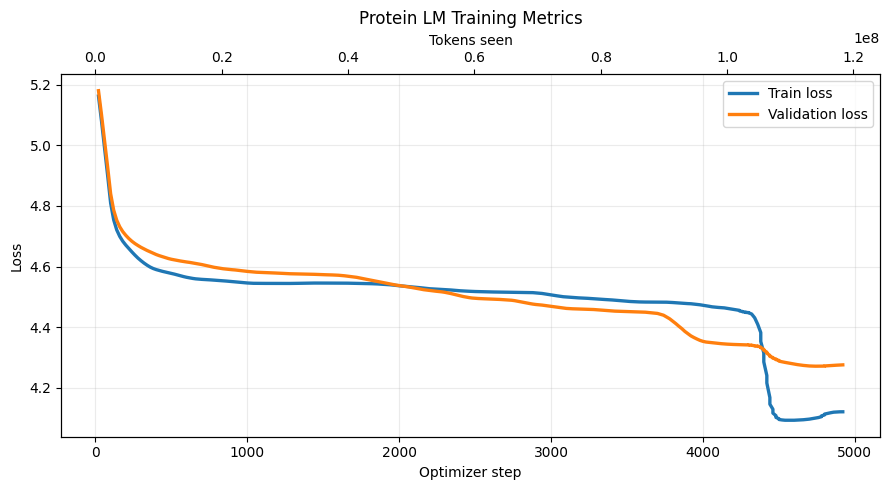

In [3]:
steps = [int(row["global_step"]) for row in rows]
train_losses = [float(row["train_loss"]) for row in rows]
val_losses = [float(row["val_loss"]) for row in rows]
tokens_seen = [int(row.get("tokens_seen", 0)) for row in rows]

SMOOTH_WINDOW = 21
SHOW_RAW = False

def smooth_loss(values, window=SMOOTH_WINDOW):
    values = np.asarray(values, dtype=float)
    if values.size < 3:
        return values
    window = min(window, values.size)
    if window % 2 == 0:
        window -= 1
    pad = window // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    median = np.array([np.median(padded[index : index + window]) for index in range(values.size)])
    mean_window = min(7, values.size)
    if mean_window % 2 == 0:
        mean_window -= 1
    mean_pad = mean_window // 2
    mean_padded = np.pad(median, (mean_pad, mean_pad), mode="edge")
    kernel = np.ones(mean_window) / mean_window
    return np.convolve(mean_padded, kernel, mode="valid")

train_losses_smooth = smooth_loss(train_losses)
val_losses_smooth = smooth_loss(val_losses)

fig, ax1 = plt.subplots(figsize=(9, 5))
if SHOW_RAW:
    ax1.plot(steps, train_losses, color="tab:blue", alpha=0.08, linewidth=0.8, label="_raw_train_loss")
    ax1.plot(steps, val_losses, color="tab:orange", alpha=0.08, linewidth=0.8, label="_raw_val_loss")
ax1.plot(steps, train_losses_smooth, color="tab:blue", label="Train loss", linewidth=2.4)
ax1.plot(steps, val_losses_smooth, color="tab:orange", label="Validation loss", linewidth=2.4)
ax1.set_title("Protein LM Training Metrics")
ax1.set_xlabel("Optimizer step")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2 = ax1.twiny()
ax2.plot(tokens_seen, train_losses_smooth, alpha=0)
ax2.set_xlabel("Tokens seen")

fig.tight_layout()
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_PATH, dpi=150)
PLOT_PATH